<a href="https://colab.research.google.com/github/mkorlyakova/MSTU-courses/blob/2025/ML%20magister/2/ML_lab1_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторная работа 1

цель работы:
  - знакомство с базовыми датасетами sklearn
  - отработка настройки алгоритма KNN


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

#Scikit-Learn

Scikit-Learn — это Python-библиотека, разработанная David Cournapeau в 2007 году и содкржит большое количество алгоритмов для задач, связанных с классификацией и машинным обучением в целом.

Scikit-Learn базируется на библиотеке SciPy, которую нужно установить перед началом работы

Установка:

In [4]:
# !pip install scikit-learn # в колаборатории этого можно не делать, в своей локальной среде необходимо обеспечить установку пакета и всех его зависимостей


### Наборы данных

Для хранения наборов данных scikit learn  :
  - использует массивы в формате numpy.array ( из библиотеки NymPy)
  - использует разреженные матрицы в формате scipy.sparse (из библиотеки SciPy)
  - поддерживает формат хранения DataFrame из библиотеки Pandas
  - имеет функции, позволяющие считывать данные из внешних файлов в форматах txt, csv, json и так далее.
  - использует наборы данных, которые поставляются вместе с библиотекой. Это открытые общеизвестные данные:
      - **данные о стоимости жилья в Бостоне**: исходя из количества комнат и уровня преступности в городе, модель может вычислять цены на жилье;
      - **данные о результатах диагностики рака молочных желез** из города Висконсина: используются для выявления злокачественного или доброкачественного новообразования;
      - **датасет химических свойств вин**: исходя из этих свойств модель может определить тип вина.



### **Задание 1.**

загрузить данные по варианту:


In [7]:
from sklearn import datasets
V1 = datasets.load_wine()
V2 = datasets.load_digits()
V3 = datasets.load_breast_cancer()
V4 = datasets.make_classification(n_samples = 10000, n_features=5, n_redundant=2, n_informative=2,random_state=10, n_clusters_per_class=2)
V5 = datasets.fetch_covtype(return_X_y=True)
V6 = datasets.make_blobs(n_samples=10000, centers=2, n_features=5, random_state=10)
V7 = datasets.make_circles(n_samples=10000, factor=0.5, noise=0.05)
V8 = datasets.make_moons(n_samples=10000, noise=0.05)


In [8]:
V1.keys(), V2.keys(), V3.keys()

(dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names']),
 dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR']),
 dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']))

In [9]:
V4[0][:2,:], V4[1][:2]

(array([[-1.53369129,  0.15903459,  0.0266148 , -0.76339466,  1.04238734],
        [ 0.15994651, -2.17701829, -1.19275252, -1.55325021,  0.00276112]]),
 array([0, 1]))

In [10]:
V5[0][:2,:5], V5[1][:2]

(array([[ 2.596e+03,  5.100e+01,  3.000e+00,  2.580e+02,  0.000e+00],
        [ 2.590e+03,  5.600e+01,  2.000e+00,  2.120e+02, -6.000e+00]]),
 array([5, 5], dtype=int32))

In [11]:
V6[0][:2,:5], V6[1][:2]

(array([[  6.04045034, -10.12182025,   3.18873994,   6.74561964,
           0.85746391],
        [  5.26263776,  -8.3128473 ,   2.6827971 ,   5.89951073,
           0.48186953]]),
 array([0, 0]))

In [12]:
V7[0][:2,:5], V7[1][:2]

(array([[ 0.51984925, -0.2603056 ],
        [ 0.53554561,  0.00206815]]),
 array([1, 1]))

 1.1.Загрузить данные  по варианту

 1.2.Опредлелить размер данных, их тип, полноту, получить основные статистики, определить тип признаков

 1.3.сделать визуализацию для 2-х координат с метками цветом по классам

 1.4.сделать выводы о качестве данных

# Метод ближайших соседей

Метод ближайших соседей (k Nearest Neighbors, или kNN) — тоже очень популярный метод классификации, также иногда используемый в задачах регрессии. Это, наравне с деревом решений, один из самых понятных подходов к классификации. На уровне интуиции суть метода такова: посмотри на соседей, какие преобладают, таков и ты. Формально основой метода является гипотезой компактности: если метрика расстояния между примерами введена достаточно удачно, то схожие примеры гораздо чаще лежат в одном классе, чем в разных.

Для классификации каждого из объектов тестовой выборки необходимо последовательно выполнить следующие операции:
 - Вычислить расстояние до каждого из объектов обучающей выборки
 - Отобрать $k$ объектов обучающей выборки, расстояние до которых минимально
 - Класс классифицируемого объекта — это класс, наиболее часто встречающийся среди $k$ ближайших соседей

 Примечательное свойство такого подхода  – его ленивость. Это значит, что вычисления начинаются только в момент классификации тестового примера, а заранее, только при  наличии обучающих примеров, никакая модель не строится.

 Методы на основе соседей известны как не обобщающие методы машинного обучения, поскольку они просто «запоминают» все свои обучающие данные



### Метод ближайших соседей в реальных задачах


Качество классификации методом ближайших соседей зависит от нескольких параметров:
 - число соседей
 - метрика расстояния между объектами (часто используются метрика Хэмминга, евклидово расстояние, косинусное расстояние и расстояние Минковского). Отметим, что при использовании большинства метрик значения признаков надо масштабировать. Условно говоря, чтобы признак "Зарплата" с диапазоном значений до 100 тысяч не вносил больший вклад в расстояние, чем "Возраст" со значениями до 100.
 - веса соседей (соседи тестового примера могут входить с разными весами, например, чем дальше пример, тем с меньшим коэффициентом учитывается его "голос")

Известная реализация метода ближайших соседей во фреймвоке SkiKit-Learn (https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).

**class** sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None) ,

где при инициализации определяем следующие параметры:

  - n_neighbors=5,
  - weights='uniform',однородные веса. Все точки в каждой окрестности имеют одинаковый вес.Кроме того, возможен вариант 'distance' : взвешивание точек обратно их расстоянию. в этом случае более близкие соседи точки запроса будут иметь большее влияние, чем соседи, которые находятся дальше. Третий вариант : **собственная функция** определяемая пользователем, которая принимает массив расстояний и возвращает массив той же формы, содержащий веса
  - algorithm : "brute", "ball_tree", "KD_tree", или "auto". В первом случае ближайшие соседи для каждого тестового примера считаются перебором обучающей выборки. Во втором и третьем - расстояние между примерами хранятся в дереве, что ускоряет нахождение ближайших соседей. В случае указания параметра "auto" подходящий способ нахождения соседей будет выбран автоматически на основе обучающей выборки.
  - leaf_size (опционально): порог переключения на полный перебор в случае выбора BallTree или KDTree для нахождения соседей
  - metric: "minkowski", "manhattan", "euclidean", "chebyshev" и другие


При работе в любой классификационной задаче необходимо выполнить следующие действия:

  1. прочитать (или создать) данные
  2. проверить их полноту и чистоту
  3. оценить размер данных и соотношение классов во множестве примеров (сбалансированные классы или нет)
  4. разделить выборку на тренировочную ( очень часто еще и на тренировочную и валидационную) и отложенную
  5. обработать примеры из тренировочной выборки, реализовать схему их обработки функционально или в рамках ООП и применить к (если есть, валидационным данным и) отложенной выборке
  6. создать объект классификатор (или несколько классификаторов для сравнения моделей различной сложности)
  7. обучить объект классификатор (или несколько объектов классификаторов)
  8. выбрать метрику для оценки модели
  9. Оценить эффективность модели (или сравнить эффективность нескольких обученных моделей)
  10 применить модель к данным отложеной выборки и определить значения выбраной метрики
  11. Сделать вывод о качестве модели


**Пример работы в KNN:**

In [14]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KDTree, BallTree
from sklearn.metrics import accuracy_score

In [15]:
data = load_iris()
X, y = data.data, data.target

In [16]:
X[0, :]

array([5.1, 3.5, 1.4, 0.2])

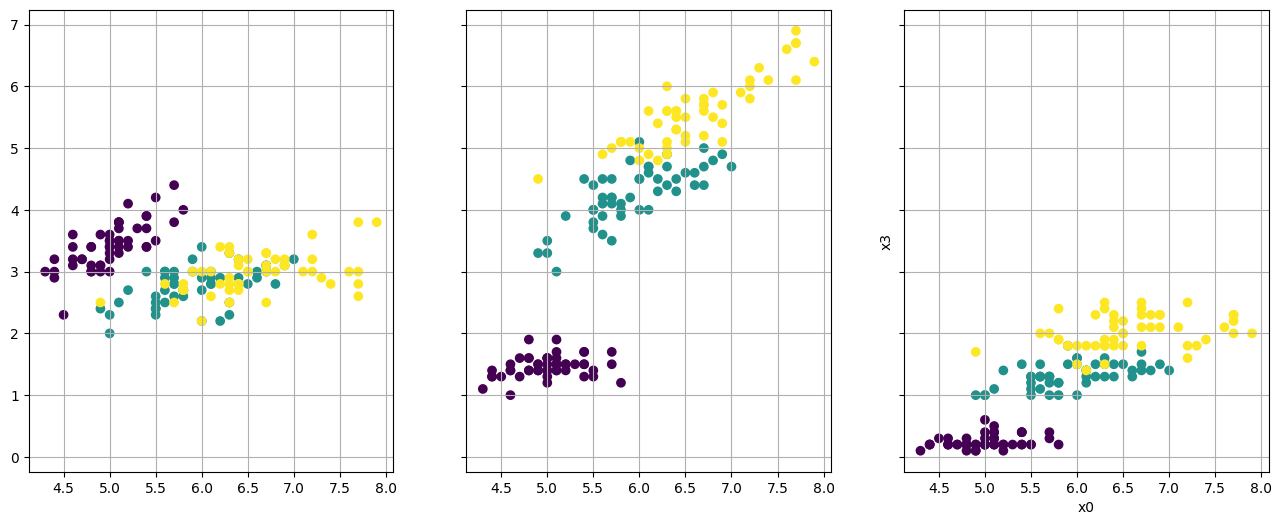

In [17]:
f, axes = plt.subplots(1, 3, sharey=True, figsize=(16, 6))
for i in range(1,4):
    axes[i-1].scatter(X[:, 0], X[:, i], c=y)
    axes[i-1].grid()

plt.xlabel('x0')
plt.ylabel('x'+str(i))
plt.show()

Посмотрим на соотношение классов в выборке, видим, что  поровну .

In [18]:
np.bincount(y)

array([50, 50, 50])

Выделим 70% выборки (X_train, y_train) под обучение и 30% будут отложенной выборкой (X_holdout, y_holdout). отложенная выборка никак не будет участвовать в настройке параметров моделей, на ней мы в конце, после этой настройки, оценим качество полученной модели.

In [19]:
# разбиение данных на тренировочные и отложенную выборку (тестовые),
#где X, y - описание примеров и их целевое свойство (классы), а test_size=0.3 - пропорция разбиения (доля тестов)
X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.3, random_state=17)
X_val, X_holdout, y_val, y_holdout = train_test_split(X_holdout, y_holdout, test_size=0.5, random_state=17)

Обучим  kNN.

In [20]:
knn = KNeighborsClassifier(n_neighbors=10)

In [21]:
%%time
knn.fit(X_train, y_train)

CPU times: user 873 µs, sys: 2.96 ms, total: 3.83 ms
Wall time: 7.18 ms


KNeighborsClassifier(n_neighbors=10)

Сделаем прогнозы для отложенной выборки. Видим, что метод ближайших соседей справился неплохо.

In [23]:
knn_pred = knn.predict(X_val)
accuracy_score(y_val, knn_pred)

0.8636363636363636

In [24]:

knn_pred = knn.predict(X_holdout)
accuracy_score(y_holdout, knn_pred)

1.0

список доступных метрик для алгоритма можно получить через свойство .valid_metrics:

In [25]:
print(sorted(KDTree.valid_metrics))

['chebyshev', 'cityblock', 'euclidean', 'infinity', 'l1', 'l2', 'manhattan', 'minkowski', 'p']


In [26]:
print(sorted(BallTree.valid_metrics))

['braycurtis', 'canberra', 'chebyshev', 'cityblock', 'dice', 'euclidean', 'hamming', 'haversine', 'infinity', 'jaccard', 'l1', 'l2', 'mahalanobis', 'manhattan', 'minkowski', 'p', 'pyfunc', 'rogerstanimoto', 'russellrao', 'seuclidean', 'sokalmichener', 'sokalsneath']


**Задание 2**

Обратите внимание, что следующие задания необходимо исполнять не менее 5 раз (5-10 реализаций) со случайным разделением на рабочую и отложенную выборки, а результаты сохраняем как среднее качество и СКО(Средняя квадратичная ошибка, MSE - mean square error ) качества. При визуализации выводим средее и границы 1 сигма.

Проверить для предществующего примера:

  2.1. число соседей : 1, 3, 5, 7, 100
  
  2.2. метрики для оценки расстояний  "manhattan", "euclidean" (для числа соседей , которое обеспечило лучший результат по accuracy) и 2 любых метрики из доступных в текущем варианте алгоритма.

  2.3. Использовать вариант с weights='distance' (для числа соседей , которое обеспечило лучший результат по accuracy)

  2.4. Сравнить результаты работы на отложенной выборке

  2.5. Построить график для accuracy от числа соседей и составить таблицу результатов для 2.2 и 2.3 (использовать 5-10 варианций для каждого набора параметров и применить "правило локтя" для оценки оптимального числа соседей)

  2.6. использовать визуализацию как в примере из [визуализация границ knn - decision boundary ](https://scikit-learn.ru/stable/auto_examples/neighbors/plot_classification.html#sphx-glr-auto-examples-neighbors-plot-classification-py) для пары координат по своему датасету
  
  2.7. разработать собственную функцию для использования в качестве аргумента в weights (использовать назначение веса от ранга примера  или как функцию расстояния) и визуализировать сравнение границ по взвещенному и не взвещенному алгоритму для одинаковой пары координат.


**Задание 3**

  3.1. Провести формирование классификатора KNN для набора по своему варианту (см. задание 1) в нескольких модификациях по числу соседей, расстояний и способов взвешивания (построить 10 вариантов)
  
  3.2. Определить вид метрики , который соответствует степени сбалансированности набора данных
  
  3.3. Сравнить варианты классификатора по метрике .

  3.4. Оценить время выполнения анализа 1000 входных векторов при условии установки параметра algorithm в каждое из слудующих значений: "brute", "ball_tree", "KD_tree".  Построить графики для оцнеки времени от числа соседей и по каждой версии алгоритма (использовать 5-10 варианций для каждого набора параметров оценить среднее и СКО)


**Задание 4**

4.1. Рассмотреть [алгоритм ближайших соседей по радиусу области](https://scikit-learn.ru/stable/modules/generated/sklearn.neighbors.RadiusNeighborsClassifier.html#sklearn.neighbors.RadiusNeighborsClassifier)

4.2. Построить решение для своего вариант в этом алгоритме и сравнить его с классическим алгоритмом классификатора KNN  

4.3. Собрать реализацию разделения областей KNN через вариант с  LSH (https://randorithms.com/2019/09/19/Visual-LSH.html, https://education.yandex.ru/handbook/ml/article/metricheskiye-metody)

4.4. оценить качество и скорость получения ответа


**Задание 5**

5.1 Сформировать реализацию формы алгоритма KNN для регрессии (ядерное сглаживание https://en.wikipedia.org/wiki/Kernel_smoother#Nearest_neighbor_smoother)

5.2. Сформировать синтетический набор данных из sklern для регрессии (например из https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_friedman3.html#sklearn.datasets.make_friedman3)

5.3. сформировать оценку качества предсказаний по правилам регрессий (МАРЕ, R2 - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

Резюме :

- В чистом виде kNN может послужить хорошим стартом (baseline) в решении какой-либо задачи;
- В соревнованиях Kaggle kNN часто используется для построения мета-признаков (прогноз kNN подается на вход прочим моделям) или в стекинге/блендинге;
- Идея ближайшего соседа расширяется и на другие задачи, например, в рекомендательных системах простым начальным решением может быть рекомендация какого-то товара (или услуги), популярного среди *ближайших соседей* человека, которому хотим сделать рекомендацию;
- На практике для больших выборок часто пользуются *приближенными* методами поиска ближайших соседей.

Вопросы для контроля:

  1. Можно ли обуществить формирование классификатора, который не ошибается
  2. Зачем нужно отложенная выборка
  3. как повлияет на результат теста увеличение числа соседей
  4. как повлияет на результат теста изменение способа оценки расстояний в алгоритме ближайщего соседа
  5. перечислите достоинства алгоритма к ближайщий сосед
  6. каковы недостатки метода к ближайщий сосед
  7. как сократить поиск в пространстве примеров соседей

Ссылки:

Метрические методы - https://education.yandex.ru/handbook/ml/article/metricheskiye-metody

[ KNN ](http://www.machinelearning.ru/wiki/index.php?title=%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%B1%D0%BB%D0%B8%D0%B6%D0%B0%D0%B9%D1%88%D0%B5%D0%B3%D0%BE_%D1%81%D0%BE%D1%81%D0%B5%D0%B4%D0%B0)

[еще KNN](http://www.machinelearning.ru/wiki/index.php?title=%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%B1%D0%BB%D0%B8%D0%B6%D0%B0%D0%B9%D1%88%D0%B8%D1%85_%D1%81%D0%BE%D1%81%D0%B5%D0%B4%D0%B5%D0%B9)

[ядерное сглаживание](http://www.machinelearning.ru/wiki/index.php?title=%D0%AF%D0%B4%D0%B5%D1%80%D0%BD%D0%BE%D0%B5_%D1%81%D0%B3%D0%BB%D0%B0%D0%B6%D0%B8%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5)

реализация sklearn - https://scikit-learn.org/stable/api/sklearn.neighbors.html